# Assignment 10: ANN Salary 

Use the same `Churn_Modelling.csv` dataset, but change the target to `EstimatedSalary`. Your goal is to practice how an ANN changes when the task changes from classification to regression.

## Required Changes
- Target: `EstimatedSalary`
- Remove `EstimatedSalary` from input features
- Output layer: 1 neuron with **linear** activation
- Loss: choose `mse` or `mae` and explain your choice
- Evaluation: MAE, RMSE and R2
- Save the model in `.keras` format
- Build and deploy a Streamlit salary prediction app

## Step 1 - Imports

In [119]:
import os
import pickle
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import( 
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf

from tensorflow import keras


## Step 2 - Load and inspect the dataset

In [120]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 3 - EDA and data quality checks

In [121]:
# shape, info, describe, missing values, duplicates, salary distribution

df.shape

(10000, 14)

In [122]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [123]:
# df.describe

# df.describe(include='all')

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


In [124]:
df.columns

#  print('Columns:', list(data.columns))

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [125]:
 # df.isnull()

# df.isnull().count

df.isnull().sum()

#print('Missing values :')
# print(df.isnull().sum())



RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [126]:
# df.duplicated().sum()

print('Duplicate Rows:', df.duplicated().sum())

Duplicate Rows: 0


In [127]:
# Salary Distribution 

df["EstimatedSalary"].describe().round(2)

count     10000.00
mean     100090.24
std       57510.49
min          11.58
25%       51002.11
50%      100193.92
75%      149388.25
max      199992.48
Name: EstimatedSalary, dtype: float64

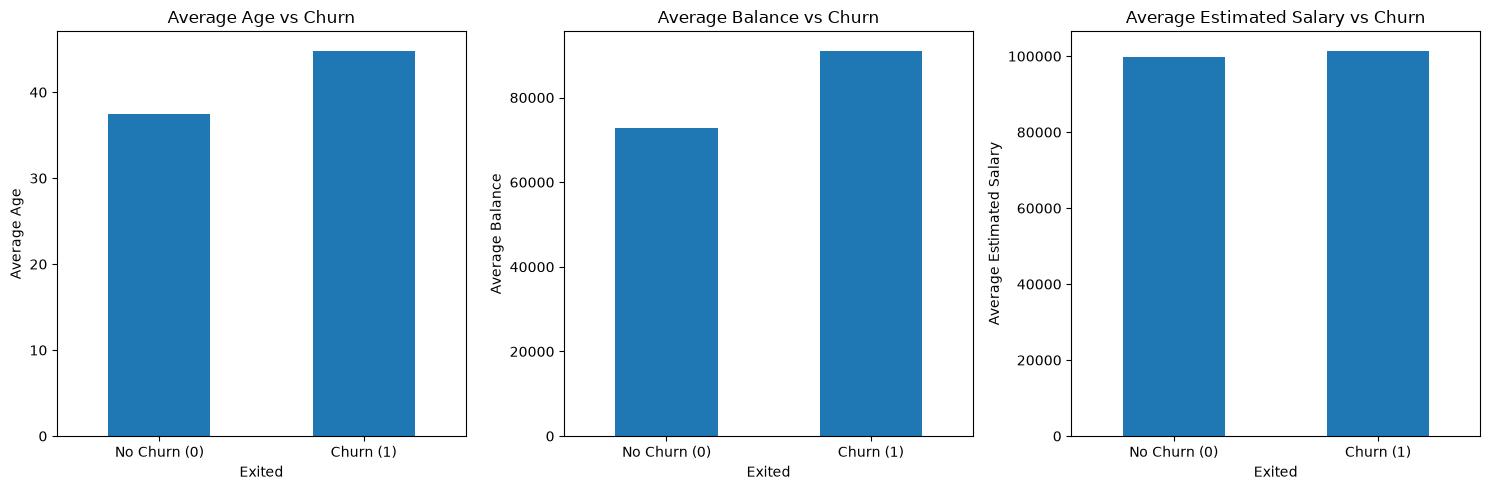

In [128]:


# Calculate average values by Exited
avg_data = df.groupby("Exited")[["Age", "Balance", "EstimatedSalary"]].mean()

# Create bar charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age vs Churn
avg_data["Age"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Age vs Churn")
axes[0].set_xlabel("Exited")
axes[0].set_ylabel("Average Age")
axes[0].set_xticklabels(["No Churn (0)", "Churn (1)"], rotation=0)

# Balance vs Churn
avg_data["Balance"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Balance vs Churn")
axes[1].set_xlabel("Exited")
axes[1].set_ylabel("Average Balance")
axes[1].set_xticklabels(["No Churn (0)", "Churn (1)"], rotation=0)

# Estimated Salary vs Churn
avg_data["EstimatedSalary"].plot(kind="bar", ax=axes[2])
axes[2].set_title("Average Estimated Salary vs Churn")
axes[2].set_xlabel("Exited")
axes[2].set_ylabel("Average Estimated Salary")
axes[2].set_xticklabels(["No Churn (0)", "Churn (1)"], rotation=0)

plt.tight_layout()
plt.show()

In [129]:
df_data = df.drop(columns=['RowNumber','CustomerId','Surname']).copy()

df_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 4 - Define X and y

In [ ]:
# y = EstimatedSalary
# X = remaining useful features

# Target
y = df_data["EstimatedSalary"].astype("float32")

# ONLY the 9 features we want to use
feature_columns = [
    "CreditScore",
    "Age",
    "Geography",
    "Tenure",
    "HasCrCard",
    "Balance",
    "IsActiveMember",
    "Gender",
    "NumOfProducts"
]

X = df_data[feature_columns].copy()

In [131]:
X.head().T
#print(X.head())

,0,1,2,3,4
CreditScore,619,608,502,699,850
Geography,France,Spain,France,France,Spain
Gender,Female,Female,Female,Female,Female
Age,42,41,42,39,43
Tenure,2,1,8,1,2
Balance,0.0,83807.86,159660.8,0.0,125510.82
NumOfProducts,1,1,3,2,1
HasCrCard,1,0,1,0,1
IsActiveMember,1,1,0,0,1
Exited,1,0,1,0,0


In [132]:
y.head()

0    101348.88
1    112542.58
2    113931.57
3     93826.63
4     79084.10
Name: EstimatedSalary, dtype: float64

In [133]:
X.shape

(10000, 10)

In [134]:
y.shape

(10000,)

## Step 5 - Train-test split and preprocessing

In [135]:
# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    
)

In [136]:
print(X_train.shape, X_test.shape)

(8000, 10) (2000, 10)


### Since we want to make all our data Numerical, Because we are using ANN, 
### To make our text columns into binary,  We use ordinalEncoder so that to make our Gender column into 1 or 0 i.e 1 for mail and 0 for female.

## Fit encoders and scaler on training data only

In [137]:
gender_encoder = OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)

gender_encoder.fit(X_train[['Gender']])

print('Gender categories : ', gender_encoder.categories_)



Gender categories :  [array(['Female', 'Male'], dtype=object)]


### We will use OnehotEncoder to handle Geography column, because we have diffrent more than two categories in data , 
### So we cannot use OrdinalEncoder, We will use OnehotEncoder.as in the following to make our Geograpy into numerical data.

In [138]:
geography_encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)

geography_encoder.fit(X_train[['Geography']])

print('Geography :', geography_encoder.categories_)

Geography : [array(['France', 'Germany', 'Spain'], dtype=object)]


### 7. A Function to  Preprocessing Gender Encoded (Text to Numeric ) Through Ordinal Encoder .
###  Geography Encoder (Text to Numeric) Through Onehotencoder .

In [139]:
def encode_features(df):
    
    df = df.copy()

    df['Gender'] = gender_encoder.transform (df[['Gender']]).ravel()

    geo_array = geography_encoder.transform(df[['Geography']])
    geo_columns = geography_encoder.get_feature_names_out(['Geography'])
    geo_df = pd.DataFrame(geo_array, columns=geo_columns, index = df.index)

    df = pd.concat([df.drop(columns='Geography'),geo_df],axis=1)

    return df


In [140]:
X_train_encoded = encode_features(X_train)
X_test_encoded = encode_features(X_test)

print('Final feature count:', X_train_encoded.shape[1])


Final feature count: 12


In [141]:
X_train_encoded.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,Geography_France,Geography_Germany,Geography_Spain
9254,686,1.0,32,6,0.00,2,1,1,0,1.0,0.0,0.0
1561,632,1.0,42,4,119624.60,2,1,1,0,0.0,1.0,0.0
1670,559,1.0,24,3,114739.92,1,1,0,1,0.0,0.0,1.0
6087,561,0.0,27,9,135637.00,1,1,0,1,1.0,0.0,0.0
6669,517,1.0,56,9,142147.32,1,0,0,1,1.0,0.0,0.0


In [142]:
X_test_encoded.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,Geography_France,Geography_Germany,Geography_Spain
6252,596,1.0,32,3,96709.07,2,0,0,0,0.0,1.0,0.0
4684,623,1.0,43,1,0.00,2,1,1,0,1.0,0.0,0.0
1731,601,0.0,44,4,0.00,2,1,0,0,0.0,0.0,1.0
4742,506,1.0,59,8,119152.10,2,1,1,0,0.0,1.0,0.0
4521,560,0.0,27,7,124995.98,1,1,1,0,0.0,0.0,1.0


### Apply Scalar = StandardScalar() , To scale our Numeric Values, So that  system can use large numeric values represented into smaller scalar equalent value. i.e 2000 = 0.20 ,  3000 = 0.30 

In [143]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_encoded)

X_test = scaler.transform(X_test_encoded)

### Idendifying our Features and Targets .

In [144]:
feature_names = list(X_train_encoded.columns)

In [145]:
print('ANN input features:', feature_names)


ANN input features: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain']


In [146]:
print('Input Shape :', X_train.shape)

Input Shape : (8000, 12)


### Saving Processing Files into Pickle files.

In [147]:
with open('gender_encoder.pkl','wb') as f:
    pickle.dump(gender_encoder, f)

In [148]:
with open('geography_encoder.pkl','wb') as f:
    pickle.dump(geography_encoder,f)

In [149]:
with open('scaler.pkl','wb') as f:
    pickle.dump(scaler,f)

In [150]:
with open('feature_names.pkl','wb') as f:
    pickle.dump(feature_names, f)

### We have converted all our data files into pickle files, this will help us to use these files to fetch data when we make front end, this will help. We dont need to built data again and again from the data set.


## Step 6 - Build a regression ANN

In [151]:
# Example structure only
# model = keras.Sequential([
#     keras.Input(shape=(X_train.shape[1],)),
#     keras.layers.Dense(64, activation='relu'),
#     keras.layers.Dense(32, activation='relu'),
#     keras.layers.Dense(1, activation='linear')
# ])

### We imported keras from tensorflow , keras 
### to create randomness in our Neural Network we set random seed . It make our experiment more reproducable. 
### It not necesserly provide guaranteed , identical results but gives every possilbe machine hardware configuration reduce in random variations. 

In [152]:
model = keras.Sequential([
#     keras.Input(shape=(X_train.shape[1],)),
#     keras.layers.Dense(64, activation='relu'),
#     keras.layers.Dense(32, activation='relu'),
#     keras.layers.Dense(1, activation='linear')
# 
])

### In above model building , Kera is using sequential input method, and providing input layer with x_train, and 
### Hidden layer 1, and Hidden layer 2 , which are using relu function/algorithm, where as in final output layer we use 
### sigmoid function , sigmoid function gives us mathematical out put more accuracy i.e 0, 0.1, 0.2, 0.3, 0.4, 0.5 ...... 1, 1.1, 1.2, 1.3, 1.4 ............2 ............etc.

### We have 12 features in our x_train , using in our model , to predict one output y.

In [153]:
shape=(X_train.shape[1])

print(shape)

12


### We Check Model Summary as follow.

In [154]:
My_model.summary()

NameError: name 'My_model' is not defined

## Step 7 - Compile and train

In [ ]:
# optimizer=Adam, loss='mse' or 'mae', include a suitable regression metric

## Model Training 

keras.utils.set_random_seed(42)

model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="linear")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# ============================================================
# 7. TRAIN
# ============================================================
history = model.fit(
    X_train,
    y_train.values,
    validation_split=0.20,
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


## Step 8 - Evaluate

In [ ]:
# Calculate MAE, RMSE and R2 on the untouched test set

 #============================================================
# 8. EVALUATE
# ============================================================
y_pred = model.predict(X_test, verbose=0).ravel()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("SALARY REGRESSION RESULTS")
print("==============================")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")
print("==============================")

# Sanity check: regression output should NOT be restricted to 0..1
print("\nPrediction range:")
print(f"Minimum prediction: ${y_pred.min():,.2f}")
print(f"Maximum prediction: ${y_pred.max():,.2f}")

def make_callbacks(run_name):
    log_dir = os.path.join(
        'logs',
        'fit',
        run_name
    )
    tensorboard_cb = keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=0
    )
    histogram_freq=0
    early_stopping_cb = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    )
    return [tensorboard_cb,early_stopping_cb]

## Step 9 - Save and reload model

In [ ]:
# ============================================================
# 9. SAVE MODEL + PREPROCESSING OBJECTS
# ============================================================
model.save("estimated_salary_model.keras")

with open("gender_encoder.pkl", "wb") as f:
    pickle.dump(gender_encoder, f)

with open("geography_encoder.pkl", "wb") as f:
    pickle.dump(geography_encoder, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)

print("\nSaved:")
print("  estimated_salary_model.keras")
print("  gender_encoder.pkl")
print("  geography_encoder.pkl")
print("  scaler.pkl")
print("  feature_names.pkl")

## Step 10 - Streamlit deployment

In [ ]:
# Build app.py, requirements.txt, README.md and deploy on Streamlit Community Cloud



## Reflection Questions
1. Why did we remove sigmoid from the output layer?
2. Why is Binary Cross-Entropy not suitable here?
3. What does MAE mean in salary units?
4. If RMSE is much larger than MAE, what might that suggest?
5. What are the limitations of predicting salary from this classroom dataset?

### 1 Why did we remove sigmoid from the output layer?

We removed sigmoid because your task is regression, not binary classification.

EstimatedSalary is a continuous numerical value (e.g., 50,000, 85,500, 120,000).
A sigmoid activation restricts the output to 0–1, which is appropriate for predicting a probability in binary classification.
For salary prediction, the model needs to be able to output a wide range of numerical values, so we use a linear activation.

### 2 = Why is Binary Cross-Entropy not suitable here?

Binary Cross-Entropy (BCE) is not suitable because EstimatedSalary is a continuous numerical target, not a binary target.

Why?

Binary Cross-Entropy is designed for binary classification, where the target has two possible classes:

0 = No
1 = Yes

### 3. What does MAE mean in salary units?

MAE (Mean Absolute Error) tells you, on average, how many salary units your model's predictions are away from the actual salaries.

For example, if your test-set MAE is:

MAE = 25,000

then We can say:

On average, the model's salary predictions are off by about 25,000 salary units.

### 4. If RMSE is much larger than MAE, what might that suggest?

If RMSE is much larger than MAE, it usually suggests that your model has some large prediction errors or outliers.

Why?
MAE treats every error proportionally.
RMSE squares the errors before averaging, so large errors are penalized much more heavily.

For example:

Actual	Predicted	Error
100,000	95,000	5,000
120,000	115,000	5,000
150,000	80,000	70,000

5. What are the limitations of predicting salary from this classroom dataset?

The main limitation is that this classroom dataset was primarily created for customer churn analysis rather than salary prediction. It lacks important salary-related features such as education, job role, work experience, and industry. Therefore, the model may have a weak relationship with EstimatedSalary, produce similar predictions for different customers, and may not generalize well to real-world salary prediction.